c:\Users\devlu\AppData\Local\Programs\Python\Python314\Lib\site-packages\yfinance\scrapers\history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed


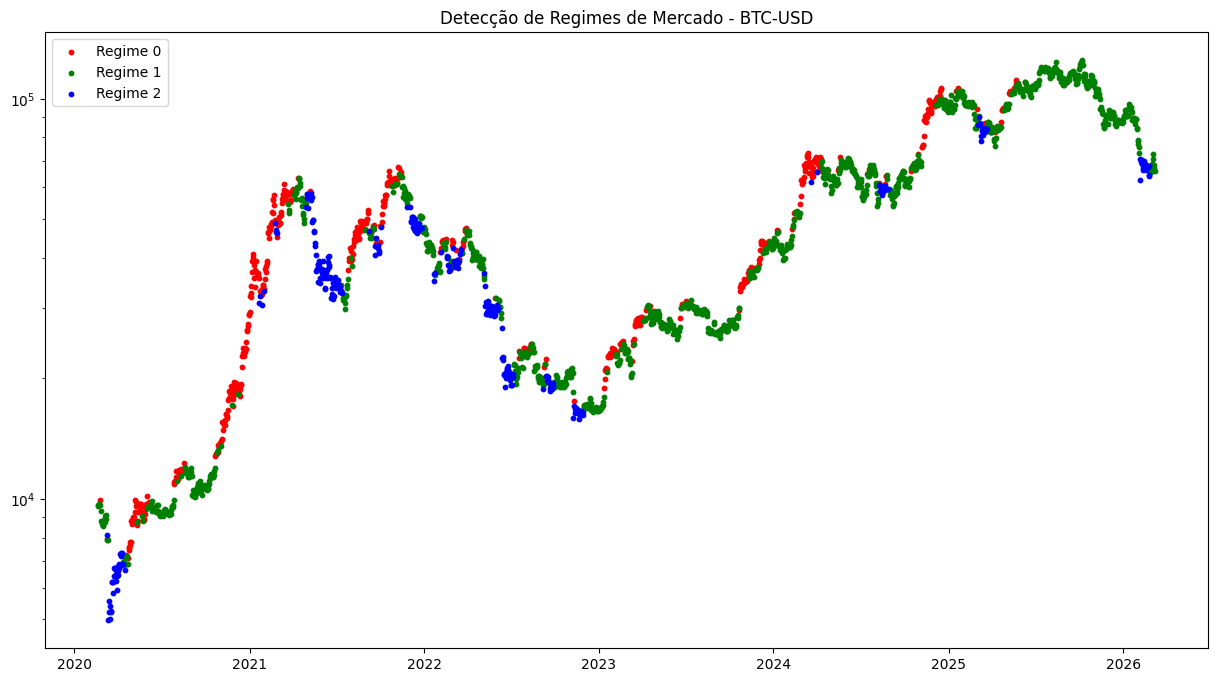

Regime
0    0.019675
1   -0.003367
2   -0.012230
Name: Returns, dtype: float64


In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Download dos dados do Bitcoin
ticker = "BTC-USD"
data = yf.download(ticker, start="2020-01-01", end="2026-03-09")

# 2. Engenharia de Features
df = data.copy()
df['Returns'] = df['Close'].pct_change()
df['Volatility'] = df['Returns'].rolling(window=20).std()
df['MA_Ratio'] = df['Close'] / df['Close'].rolling(window=50).mean() # Proximidade da média móvel

# Limpeza (remover NaNs criados pelas janelas móveis)
df = df.dropna()

# 3. Preparação para o Machine Learning
# Selecionamos as variáveis que o modelo usará para "aprender" os regimes
features = ['Returns', 'Volatility', 'MA_Ratio']
X = df[features]

# Normalização (Essencial para K-Means!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Treino do Modelo K-Means (3 regimes: Bull, Bear, Sideways)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Regime'] = kmeans.fit_predict(X_scaled)

# 5. Visualização
plt.figure(figsize=(15, 8))
colors = ['red', 'green', 'blue'] # O K-Means atribui labels 0, 1, 2 aleatoriamente

for i in range(3):
    mask = df['Regime'] == i
    plt.scatter(df.index[mask], df['Close'][mask], label=f'Regime {i}', s=10, color=colors[i])

plt.title(f"Detecção de Regimes de Mercado - {ticker}")
plt.yscale('log') # Escala logarítmica é melhor para BTC
plt.legend()
plt.show()

# Dica: Olhe os retornos médios de cada regime para saber qual é qual
print(df.groupby('Regime')['Returns'].mean())